# Engine Knock Prediction with a Transformer

This notebook forecasts the engine **knock-sensor pressure signal** with a Transformer.
Raw cylinder-pressure data (per crank angle, per cycle) is serialized into one long
time series, knock events are labelled with a band-pass + threshold (MAPO-style)
detector, and an encoder-only Transformer learns to predict the next stretch of the
signal from a window of past samples. Finally, knock is **derived from the forecast**
and scored against the ground truth.

**Pipeline**
1. **Data loading & preprocessing** - read a fuel-blend sheet, serialize it, label knock.
2. **Inspection** - plot the signal with the detected knock points.
3. **Windowed dataset** - build sliding-window (past -> future) forecasting samples.
4. **Model** - encoder-only Transformer with a direct multi-step head.
5. **Training** - train and validate on a temporal split.
6. **Knock prediction & evaluation** - report metrics and plot predicted vs. ground truth.

In [1]:
import math

import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
# ---- Data / training config ----
DATA_PATH  = "MethodsX Data 1400 rpm.xlsx"
BLEND      = "100D"      # one of: "100D", "90D10G", "80D20G", "70D30G", "60D40G"
INPUT_LEN  = 360         # context length fed to the model (= one full engine cycle)
OUTPUT_LEN = 90          # number of future steps to forecast
STRIDE     = 4           # sliding-window stride (1 = densest, larger = fewer/faster windows)
BATCH_SIZE = 1024
EPOCHS     = 10
LR         = 5e-3
VAL_FRAC   = 0.2         # fraction of the (temporal) signal held out for validation

# ---- Model config ----
IN_CHANNELS  = 2         # input features per step: [pressure, knock]
OUT_CHANNELS = 1         # forecast pressure only
D_MODEL      = 64
N_HEAD       = 1
N_LAYERS     = 3
DIM_FF       = 128
DROPOUT      = 0.1

In [3]:
# Quick environment check - tells you whether training will run on GPU or CPU.
print("torch:", torch.__version__)             # e.g. 2.x.x+cu121 (GPU build) or +cpu
print("built for CUDA:", torch.version.cuda)    # None = CPU-only build
print("CUDA available:", torch.cuda.is_available())

torch: 2.8.0+cu128
built for CUDA: 12.8
CUDA available: True


## 1. Data loading & preprocessing

`load_blend` reads one fuel-blend sheet into a `(360 crank angles, 500 cycles)` array.
`preprocess` then:
- serializes the array **column-major**, so cycles sit end-to-end in time order, and
- labels **knock** per sample by band-pass filtering the pressure to isolate the
  high-frequency ringing and flagging samples whose amplitude exceeds `k x` the
  baseline-noise standard deviation, within the post-TDC knock window.

It returns a structured array of `('pressure', 'knock')` entries (length 180,000).

In [4]:
def load_blend(blend, path=DATA_PATH):
    """Load one blend sheet (e.g. '100D', '90D10G') into a 2D numpy array.
    Returns array of shape (360 crank angles, 500 cycles)."""
    df = pd.read_excel(path, sheet_name=blend, header=None)
    return df.iloc[3:, 3:].to_numpy(dtype=float)   # (360, 500)
data = load_blend(BLEND)

In [5]:
def preprocess(data, rpm=1400, crank_angle=None,
               knock_band=(1200, 4000),          # Hz; must stay below Nyquist = fs/2
               knock_window=(0.0, 50.0),         # deg ATDC: where knock can physically occur
               baseline_window=(-160.0, -40.0),  # knock-free region, used to set the threshold
               k=4.0):                           # threshold = k * baseline noise std
    """data: (360 crank angles, 500 cycles) from load_blend(...).
    Returns a structured array of length 180000; each entry has
    ('pressure', float) and ('knock', bool)."""
    n_ca, n_cyc = data.shape
    if crank_angle is None:
        crank_angle = np.arange(-180, 180)       # -180 .. +179
    fs = rpm / 60 * 360                           # 8400 Hz here (1 sample/deg)

    # 1) Serialize into time order. Each COLUMN is one cycle's crank sweep,
    #    so stacking columns end-to-end makes every sample adjacent in time
    #    to the one before/after it. Cycle boundaries disappear.
    pressure = data.flatten(order='F')            # column-major (Fortran) order
    ca = np.tile(crank_angle, n_cyc)              # crank angle aligned to each sample

    # 2) Knock detection: band-pass to isolate the high-frequency "ringing",
    #    then flag samples whose oscillation amplitude exceeds a noise-based
    #    threshold, restricted to the post-TDC knock window. (MAPO-style.)
    nyq = fs / 2
    hi = min(knock_band[1], 0.99 * nyq)
    b, a = butter(4, [knock_band[0] / nyq, hi / nyq], btype='band')
    osc = filtfilt(b, a, pressure)

    base = (ca >= baseline_window[0]) & (ca <= baseline_window[1])
    win  = (ca >= knock_window[0])    & (ca <= knock_window[1])
    sigma = osc[base].std()                       # mechanical/combustion noise floor
    knock = (np.abs(osc) > k * sigma) & win       # per-sample boolean

    out = np.empty(pressure.size, dtype=[('pressure', float), ('knock', bool)])
    out['pressure'] = pressure
    out['knock'] = knock
    return out
out  = preprocess(data)

## 2. Inspect the signal & knock labels

Plot a short slice of the serialized signal (~ 2 engine cycles) with the detected
knock points overlaid in red and dashed lines at the cycle boundaries. Use this to
sanity-check that the detector fires where you expect before training on the labels.

In [6]:
def plot_window(out, start, n=720):
    """Plot the serialized pressure over `n` samples starting at `start`,
    overlaying points flagged as knock. 720 samples = 2 cycles (360 deg each)."""
    end = min(start + n, out.shape[0])
    seg = out[start:end]
    idx = np.arange(start, end)
    k = seg['knock']

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(idx, seg['pressure'], lw=0.8, color='steelblue', label='pressure')
    ax.scatter(idx[k], seg['pressure'][k], color='red', s=22, zorder=5,
               label=f'knock ({int(k.sum())} pts)')

    # dashed lines at cycle boundaries (every 360 samples)
    for b in range((start // 360 + 1) * 360, end, 360):
        ax.axvline(b, color='gray', ls='--', lw=0.6, alpha=0.6)

    ax.set_xlabel('serialized sample index  (1 per crank angle)')
    ax.set_ylabel('knock-sensor signal')
    ax.set_title(f'samples {start}\u2013{end-1}   ({int(k.sum())} knock points)')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    return fig

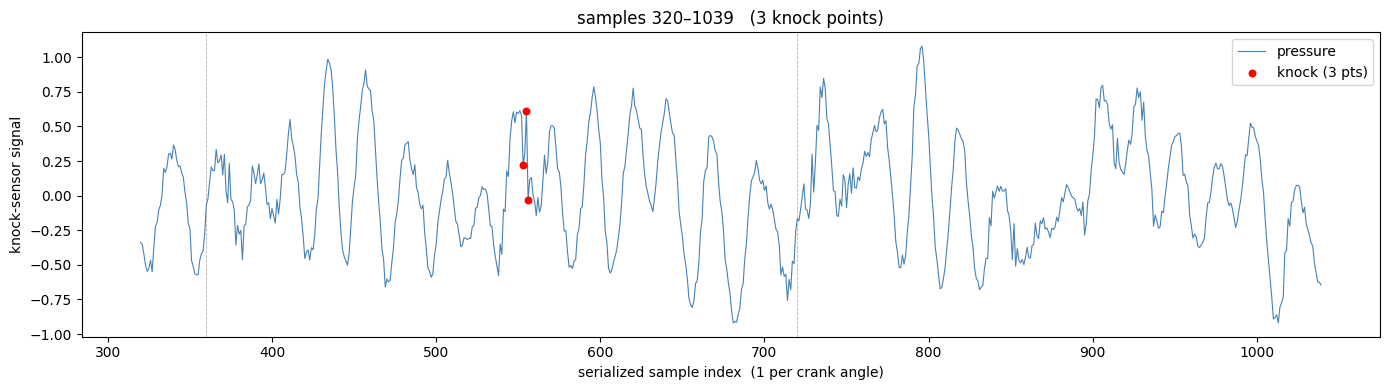

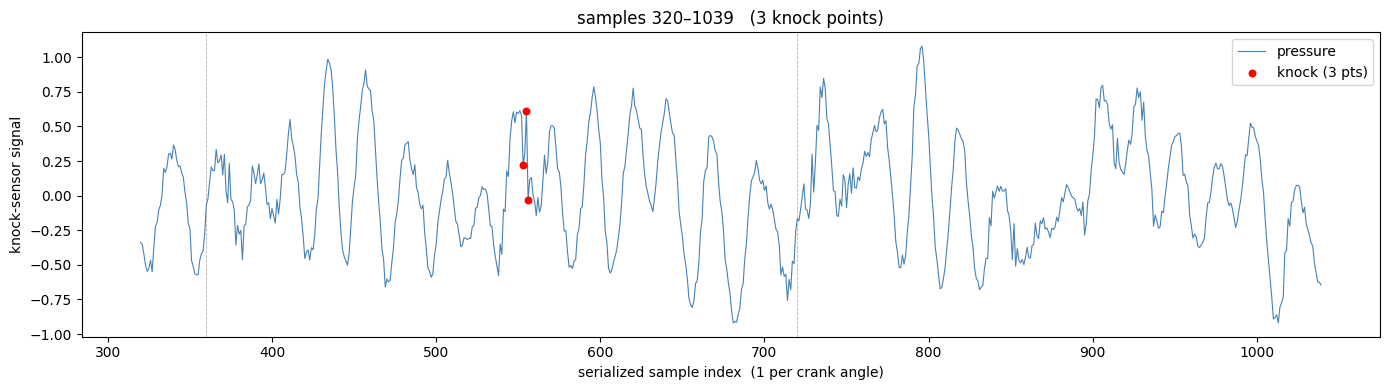

In [7]:
plot_window(out, start=320)     # 720 samples ~ 2 full cycles

## 3. Windowed forecasting dataset

`KnockWindowDataset` turns the serialized signal into sliding-window samples:
- **x** = `INPUT_LEN` past steps of `[normalized pressure, knock flag]`
- **y** = the next `OUTPUT_LEN` steps of normalized pressure

`make_loaders` splits the signal **temporally** by `VAL_FRAC` (earliest part -> train,
the rest -> val) and reuses the *training* mean/std to normalize the validation set,
avoiding leakage.

In [8]:
class KnockWindowDataset(Dataset):
    """Sliding-window forecasting samples from a serialized (pressure, knock) array.

    x: (INPUT_LEN, 2)  -> [normalized pressure, knock flag]
    y: (OUTPUT_LEN, 1) -> normalized pressure of the steps immediately after x
    """
    def __init__(self, out, input_len=INPUT_LEN, output_len=OUTPUT_LEN,
                 stride=STRIDE, mean=None, std=None):
        p = out['pressure'].astype('float32')
        k = out['knock'].astype('float32')

        # standardize pressure (knock is already 0/1). Stats can be injected so
        # the validation split reuses the TRAIN statistics (no leakage).
        self.mean = float(p.mean()) if mean is None else float(mean)
        self.std  = float(p.std() + 1e-8) if std is None else float(std)
        p_n = (p - self.mean) / self.std

        self.X = np.stack([p_n, k], axis=1)               # (N, 2)
        self.target = p_n                                 # (N,)
        self.input_len = input_len
        self.output_len = output_len
        last = len(p) - input_len - output_len + 1
        self.starts = np.arange(0, max(last, 0), stride)

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, idx):
        s = self.starts[idx]
        x = self.X[s: s + self.input_len]                                  # (L_in, 2)
        y = self.target[s + self.input_len: s + self.input_len + self.output_len]  # (L_out,)
        return torch.from_numpy(x), torch.from_numpy(y[:, None])           # y -> (L_out, 1)


def make_loaders(out, batch_size=BATCH_SIZE, val_frac=VAL_FRAC,
                 input_len=INPUT_LEN, output_len=OUTPUT_LEN, stride=STRIDE):
    """Temporal split: earliest (1-val_frac) of the signal for train, rest for val."""
    N = out.shape[0]
    split = int(N * (1 - val_frac))
    train_ds = KnockWindowDataset(out[:split], input_len, output_len, stride)
    val_ds = KnockWindowDataset(out[split:], input_len, output_len, stride,
                                mean=train_ds.mean, std=train_ds.std)   # reuse train stats
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_dl, val_dl, (train_ds.mean, train_ds.std)

## 4. Transformer model

An encoder-only Transformer with sinusoidal positional encoding. It encodes the input
window, **mean-pools** over time, and a small MLP head projects to all `OUTPUT_LEN`
future steps at once - direct multi-step forecasting, with no autoregressive decoding.

In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=4096):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))       # (1, max_len, d_model)

    def forward(self, x):                                 # x: (B, L, d_model)
        return x + self.pe[:, :x.size(1)]


class KnockTransformer(nn.Module):
    """Encoder-only transformer for direct multi-step forecasting.

    Encodes the INPUT_LEN window, mean-pools over time, and projects to the
    full OUTPUT_LEN horizon in one shot (no autoregressive decoding).
    """
    def __init__(self, in_channels=IN_CHANNELS, out_channels=OUT_CHANNELS,
                 out_len=OUTPUT_LEN, d_model=D_MODEL, nhead=N_HEAD,
                 num_layers=N_LAYERS, dim_ff=DIM_FF, dropout=DROPOUT):
        super().__init__()
        self.out_len = out_len
        self.out_channels = out_channels
        self.input_proj = nn.Linear(in_channels, d_model)
        self.pos = PositionalEncoding(d_model)
        layer = nn.TransformerEncoderLayer(d_model, nhead, dim_ff, dropout,
                                           batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, dim_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim_ff, out_len * out_channels),
        )

    def forward(self, x):                                 # x: (B, L_in, in_channels)
        h = self.input_proj(x)
        h = self.pos(h)
        h = self.encoder(h)                               # (B, L_in, d_model)
        h = h.mean(dim=1)                                 # (B, d_model)
        out = self.head(h)                                # (B, out_len*out_channels)
        return out.view(-1, self.out_len, self.out_channels)  # (B, out_len, out_channels)

## 5. Training

Train with MSE loss and Adam over the temporal train/validation split, printing the
train and validation MSE each epoch. `train()` returns the fitted model, which the
next cell captures as `model` so the evaluation/plot steps below can use it.

In [10]:
def train():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    out = preprocess(load_blend(BLEND))
    train_dl, val_dl, (mu, sd) = make_loaders(out)

    model = KnockTransformer().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()

    n_params = sum(p.numel() for p in model.parameters())
    print(f"device={device}  params={n_params:,}  "
          f"train_batches={len(train_dl)}  val_batches={len(val_dl)}")

    for epoch in range(1, EPOCHS + 1):
        model.train()
        tr = 0.0
        for x, y in train_dl:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            opt.step()
            tr += loss.item() * x.size(0)
        tr /= len(train_dl.dataset)

        model.eval()
        va = 0.0
        with torch.no_grad():
            for x, y in val_dl:
                x, y = x.to(device), y.to(device)
                va += loss_fn(model(x), y).item() * x.size(0)
        va /= len(val_dl.dataset)
        print(f"epoch {epoch:2d}  train_mse={tr:.4f}  val_mse={va:.4f}")

    return model

In [11]:
model = train()

/opt/conda/envs/cse234/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


device=cuda  params=120,538  train_batches=35  val_batches=9
epoch  1  train_mse=0.9762  val_mse=0.7466
epoch  2  train_mse=0.6545  val_mse=0.4408
epoch  3  train_mse=0.4929  val_mse=0.3404
epoch  4  train_mse=0.3583  val_mse=0.2714
epoch  5  train_mse=0.2947  val_mse=0.2123
epoch  6  train_mse=0.2633  val_mse=0.1995
epoch  7  train_mse=0.2311  val_mse=0.1812
epoch  8  train_mse=0.2180  val_mse=0.1838
epoch  9  train_mse=0.2094  val_mse=0.1653
epoch 10  train_mse=0.2012  val_mse=0.1557


## 6. Knock prediction & evaluation

The model forecasts pressure, so **knock is derived from the forecast**: the predicted
pressure horizon is band-pass filtered and thresholded with the same MAPO-style rule
used for the labels (using the baseline-noise floor of the full signal).

- `evaluate` runs the model over the validation split and reports **pressure** metrics
  (MSE, MAE, R2) plus **knock** classification metrics (accuracy, precision, recall, F1).
- `plot_prediction` overlays the predicted pressure/knock against the ground truth for a
  single forecast window.

> Note: forecasting the exact high-frequency knock ringing is hard, so knock recall is
> typically the limiting metric - the plot makes it easy to see where the model agrees.

In [12]:
def _bandpass(rpm=1400, knock_band=(1200, 4000)):
    """4th-order Butterworth band-pass used to isolate the knock ringing."""
    nyq = (rpm / 60 * 360) / 2
    hi = min(knock_band[1], 0.99 * nyq)
    return butter(4, [knock_band[0] / nyq, hi / nyq], btype='band')


def baseline_sigma(out, rpm=1400, knock_band=(1200, 4000), baseline_window=(-160., -40.)):
    """Noise floor from the knock-free baseline window (same basis preprocess uses)."""
    b, a = _bandpass(rpm, knock_band)
    p = out['pressure'].astype(float)
    ca = (np.arange(out.shape[0]) % 360) - 180
    base = (ca >= baseline_window[0]) & (ca <= baseline_window[1])
    return filtfilt(b, a, p)[base].std()


@torch.no_grad()
def evaluate(model, out, mu, sd, val_frac=VAL_FRAC, batch_size=BATCH_SIZE,
             knock_window=(0., 50.), k=4.0):
    """Forecast the validation split, then report pressure + derived-knock metrics."""
    device = next(model.parameters()).device
    model.eval()

    split = int(out.shape[0] * (1 - val_frac))
    val_part = out[split:]
    ds = KnockWindowDataset(val_part, mean=mu, std=sd)   # reuse train stats
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False)

    preds, trues = [], []
    for x, y in dl:
        preds.append(model(x.to(device)).cpu().numpy()[..., 0])   # (B, OUTPUT_LEN)
        trues.append(y.numpy()[..., 0])
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    pred_p = preds * sd + mu                                       # de-normalize
    true_p = trues * sd + mu

    # ---- pressure regression metrics ----
    mse = float(np.mean((pred_p - true_p) ** 2))
    mae = float(np.mean(np.abs(pred_p - true_p)))
    ss_res = np.sum((true_p - pred_p) ** 2)
    ss_tot = np.sum((true_p - true_p.mean()) ** 2)
    r2 = float(1 - ss_res / ss_tot) if ss_tot > 0 else float('nan')

    # ---- knock derived from the forecast vs. the ground-truth labels ----
    sigma = baseline_sigma(out)
    b, a = _bandpass()
    osc = filtfilt(b, a, pred_p, axis=-1)                         # band-pass each horizon
    g = split + ds.starts + INPUT_LEN                             # global index per horizon
    ca = (g[:, None] + np.arange(OUTPUT_LEN)[None, :]) % 360 - 180
    win = (ca >= knock_window[0]) & (ca <= knock_window[1])
    pred_knock = (np.abs(osc) > k * sigma) & win

    loc = ds.starts[:, None] + INPUT_LEN + np.arange(OUTPUT_LEN)[None, :]
    true_knock = val_part['knock'][loc]

    tp = int(np.sum(pred_knock & true_knock));  fp = int(np.sum(pred_knock & ~true_knock))
    fn = int(np.sum(~pred_knock & true_knock)); tn = int(np.sum(~pred_knock & ~true_knock))
    acc  = (tp + tn) / max(tp + tn + fp + fn, 1)
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0

    print(f"Pressure  MSE={mse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")
    print(f"Knock     acc={acc:.4f}  precision={prec:.4f}  recall={rec:.4f}  F1={f1:.4f}")
    print(f"          knock samples: true={int(true_knock.sum())}  "
          f"pred={int(pred_knock.sum())}  of {true_knock.size}")
    return dict(mse=mse, mae=mae, r2=r2, acc=acc, precision=prec, recall=rec, f1=f1, sigma=sigma)

In [13]:
out = preprocess(load_blend(BLEND))          # same deterministic preprocessing as training
_, _, (mu, sd) = make_loaders(out)           # recover the train-set normalization stats
metrics = evaluate(model, out, mu, sd)

Pressure  MSE=0.0218  MAE=0.1165  R2=0.8279
Knock     acc=0.9956  precision=0.0000  recall=0.0000  F1=0.0000
          knock samples: true=3489  pred=0  of 799920


In [14]:
@torch.no_grad()
def plot_prediction(model, out, mu, sd, start, sigma=None, knock_window=(0., 50.), k=4.0):
    """Forecast the OUTPUT_LEN steps after `start + INPUT_LEN` and overlay the
    predicted pressure/knock against the ground truth for that window."""
    device = next(model.parameters()).device
    model.eval()

    p  = out['pressure'].astype('float32')
    kf = out['knock'].astype('float32')
    p_n = (p - mu) / sd
    x = np.stack([p_n, kf], axis=1)[start:start + INPUT_LEN]      # (INPUT_LEN, 2)
    pred_n = model(torch.from_numpy(x[None]).to(device)).cpu().numpy()[0, :, 0]
    pred_p = pred_n * sd + mu                                     # de-normalize

    h0, h1 = start + INPUT_LEN, start + INPUT_LEN + OUTPUT_LEN
    true_p = p[h0:h1].astype(float)
    true_knock = out['knock'][h0:h1]

    # predicted knock from the forecasted pressure
    if sigma is None:
        sigma = baseline_sigma(out)
    b, a = _bandpass()
    osc = filtfilt(b, a, pred_p)
    ca = (np.arange(h0, h1) % 360) - 180
    win = (ca >= knock_window[0]) & (ca <= knock_window[1])
    pred_knock = (np.abs(osc) > k * sigma) & win

    idx = np.arange(h0, h1)
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(np.arange(start, h0), p[start:h0], color='lightgray', lw=0.8, label='input context')
    ax.plot(idx, true_p, color='steelblue', lw=1.3, label='true pressure')
    ax.plot(idx, pred_p, color='darkorange', lw=1.3, ls='--', label='predicted pressure')
    ax.scatter(idx[true_knock], true_p[true_knock], color='red', s=40, zorder=5,
               label='true knock')
    ax.scatter(idx[pred_knock], pred_p[pred_knock], color='purple', marker='x', s=55, zorder=6,
               label='predicted knock')
    ax.axvline(h0, color='gray', ls=':', lw=1)
    ax.set_xlabel('serialized sample index  (1 per crank angle)')
    ax.set_ylabel('knock-sensor signal')
    ax.set_title(f'forecast @ start={start}   horizon MSE={np.mean((pred_p - true_p) ** 2):.3f}')
    ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()
    return fig

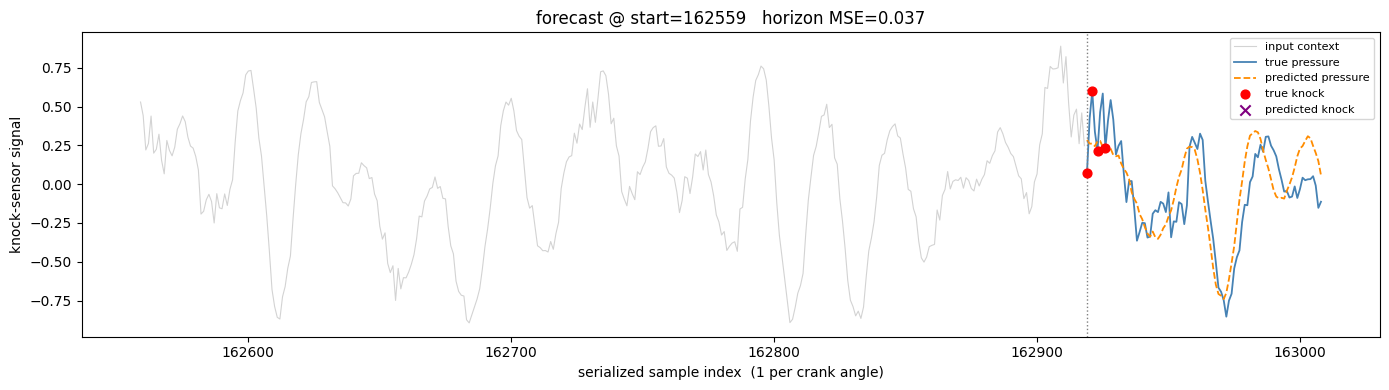

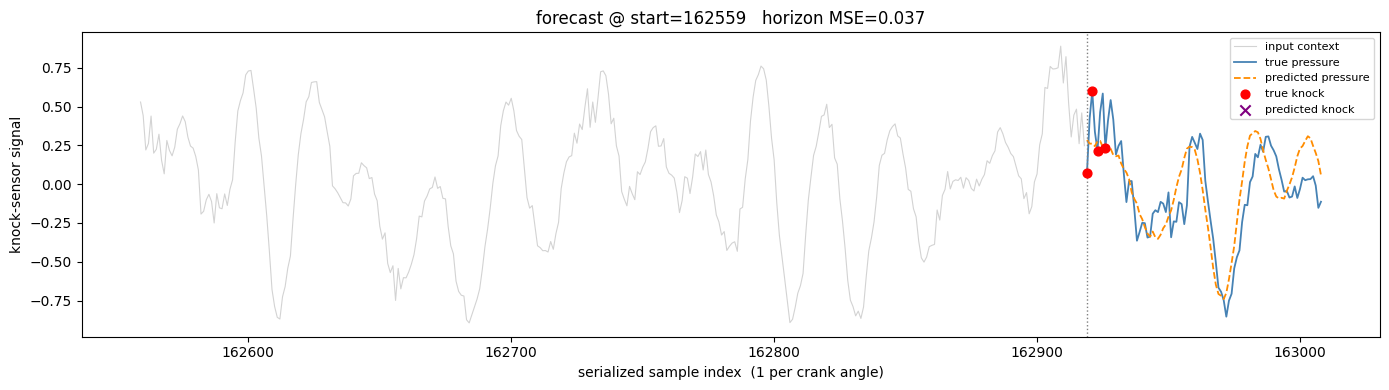

In [15]:
# Pick a validation window whose forecast horizon actually contains a knock event.
split = int(out.shape[0] * (1 - VAL_FRAC))
kidx = np.where(out['knock'])[0]
kidx = kidx[(kidx >= split + INPUT_LEN) & (kidx < out.shape[0] - OUTPUT_LEN)]
start = int(kidx[len(kidx) // 2]) - INPUT_LEN if len(kidx) else split

plot_prediction(model, out, mu, sd, start=start)